In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Ustawienia wykresów
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style = 'whitegrid')

#Wczytanie danych
df = pd.read_csv('Sample - Superstore.csv', encoding = 'latin-1')

print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
#Czyszczenie danych
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#Dodawanie nowych przydatnych kolumn
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

#Sprawdzenie
print(df[['Order Date', 'Ship Date', 'Year', 'Month', 'Days to Ship']].head())

  Order Date  Ship Date  Year  Month  Days to Ship
0 2016-11-08 2016-11-11  2016     11             3
1 2016-11-08 2016-11-11  2016     11             3
2 2016-06-12 2016-06-16  2016      6             4
3 2015-10-11 2015-10-18  2015     10             7
4 2015-10-11 2015-10-18  2015     10             7


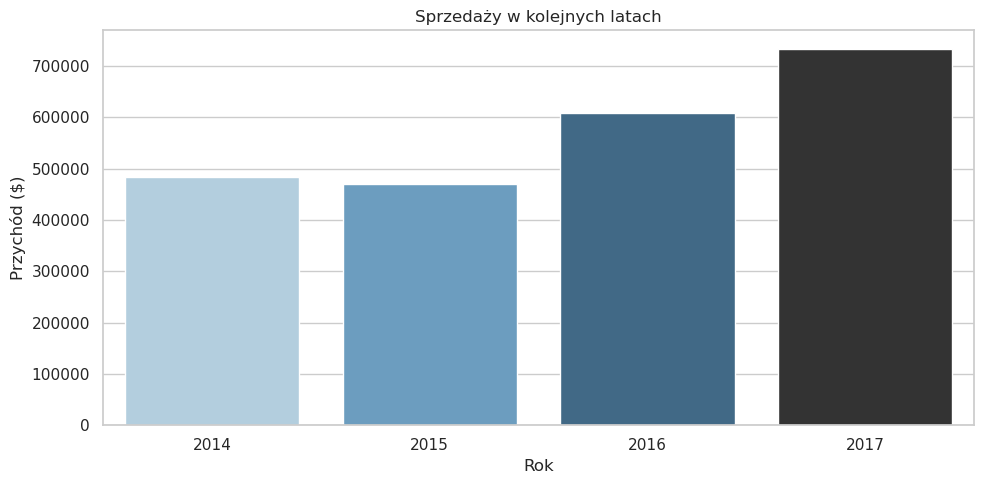

   Year        Sales
0  2014  484247.4981
1  2015  470532.5090
2  2016  609205.5980
3  2017  733215.2552


In [7]:
#Wykres sprzedaż w każdym osobnym roku
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_sales, x='Year', y='Sales', hue='Year', legend=False, palette='Blues_d')
plt.title('Sprzedaży w kolejnych latach')
plt.ylabel('Przychód ($)')
plt.xlabel('Rok')
plt.tight_layout()
plt.show()

print(yearly_sales)

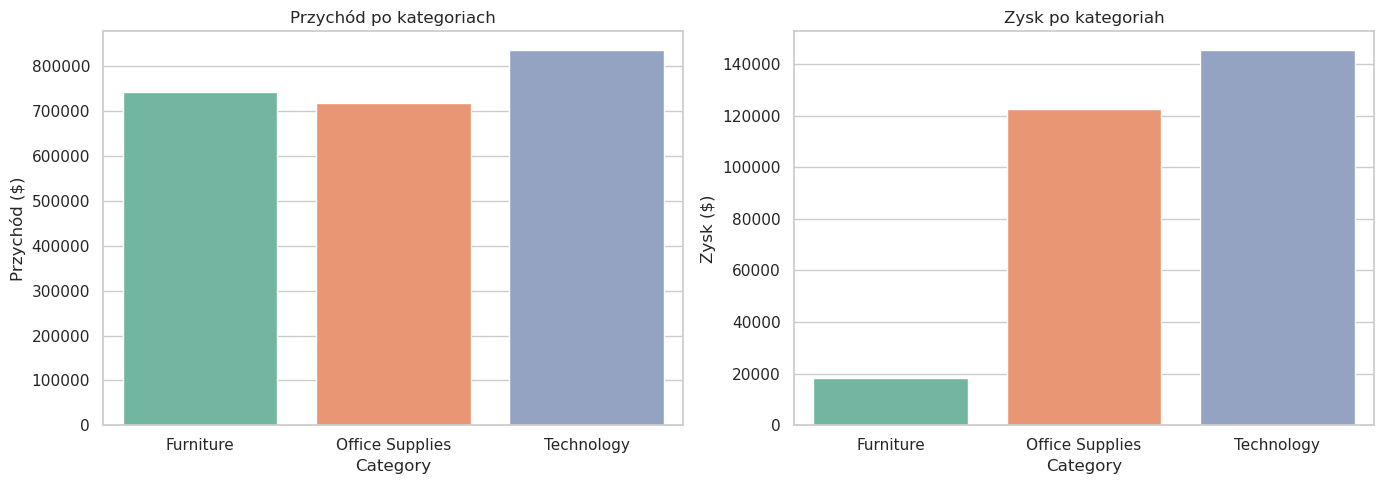

In [8]:
#Sprzedaży po kategoriach
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=category_sales, x='Category', y='Sales', hue='Category', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Przychód po kategoriach')
axes[0].set_ylabel('Przychód ($)')

sns.barplot(data=category_profit, x='Category', y='Profit', hue='Category', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('Zysk po kategoriah')
axes[1].set_ylabel('Zysk ($)')

plt.tight_layout()
plt.show()

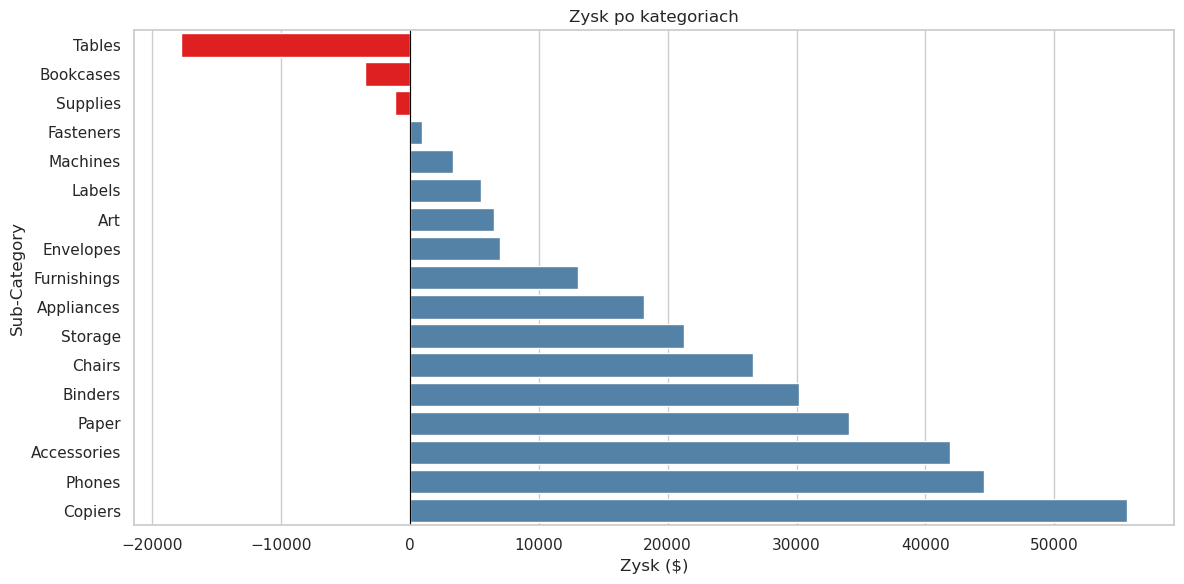

In [9]:
#Zysk po podkategoriach
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
subcategory_profit = subcategory_profit.sort_values('Profit')

plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'steelblue' for x in subcategory_profit['Profit']]
sns.barplot(data=subcategory_profit, x='Profit', y='Sub-Category', hue='Sub-Category', legend=False, palette=colors)
plt.title('Zysk po kategoriach')
plt.xlabel('Zysk ($)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

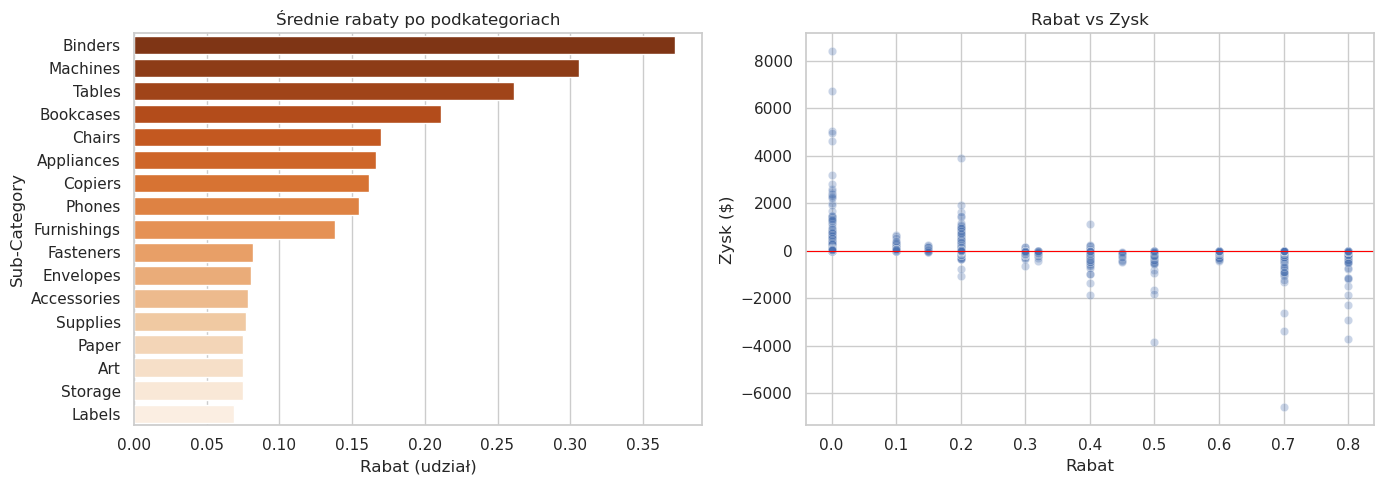

In [10]:
#Sprawdzenie przyczyny czemu niektóre kategorie nierentowe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Rabaty po podkategoriach
subcategory_discount = df.groupby('Sub-Category')['Discount'].mean().reset_index()
subcategory_discount = subcategory_discount.sort_values('Discount', ascending=False)

sns.barplot(data=subcategory_discount, x='Discount', y='Sub-Category', hue='Sub-Category', legend=False, palette='Oranges_r', ax=axes[0])
axes[0].set_title('Średnie rabaty po podkategoriach')
axes[0].set_xlabel('Rabat (udział)')

#Związek rabatu i zysku
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3, ax=axes[1])
axes[1].set_title('Rabat vs Zysk')
axes[1].set_xlabel('Rabat')
axes[1].set_ylabel('Zysk ($)')
axes[1].axhline(y=0, color='red', linewidth=0.8)

plt.tight_layout()
plt.show()

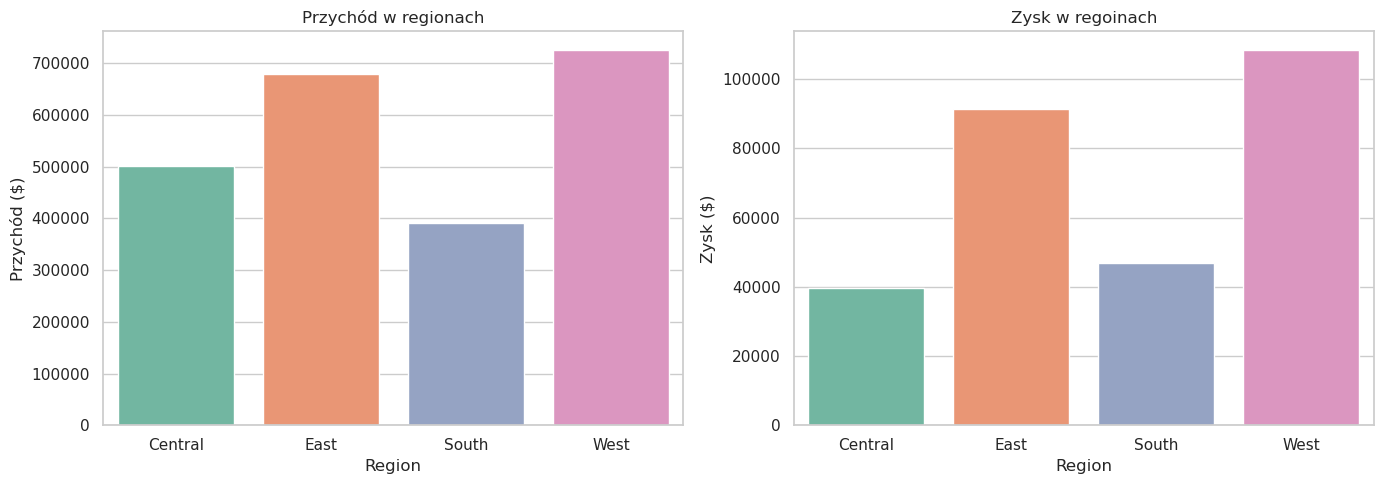

    Region        Sales       Profit
0  Central  501239.8908   39706.3625
1     East  678781.2400   91522.7800
2    South  391721.9050   46749.4303
3     West  725457.8245  108418.4489


In [11]:
#Zysk po regionch
region_profit = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_profit, x='Region', y='Sales', hue='Region', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Przychód w regionach')
axes[0].set_ylabel('Przychód ($)')

sns.barplot(data=region_profit, x='Region', y='Profit', hue='Region', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('Zysk w regoinach')
axes[1].set_ylabel('Zysk ($)')

plt.tight_layout()
plt.show()

print(region_profit)

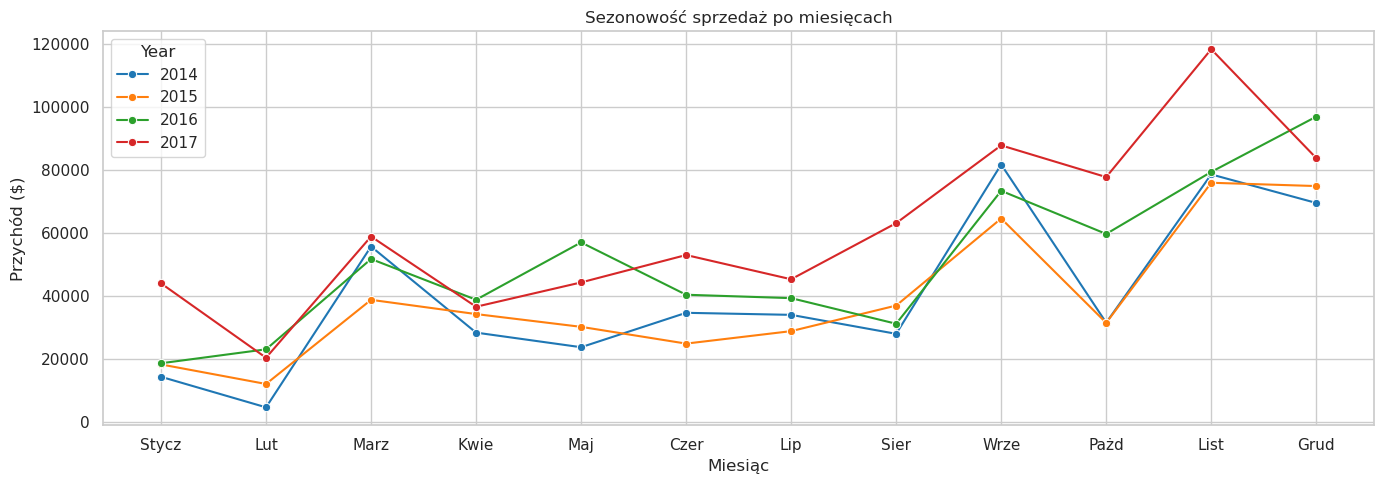

In [12]:
#Sezonowość sprzedaż
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', palette='tab10', marker='o')
plt.title('Sezonowość sprzedaż po miesięcach')
plt.xlabel('Miesiąc')
plt.ylabel('Przychód ($)')
plt.xticks(range(1, 13), ['Stycz', 'Lut', 'Marz', 'Kwie', 'Maj', 'Czer', 'Lip', 'Sier', 'Wrze', 'Pażd', 'List', 'Grud'])
plt.tight_layout()
plt.show()

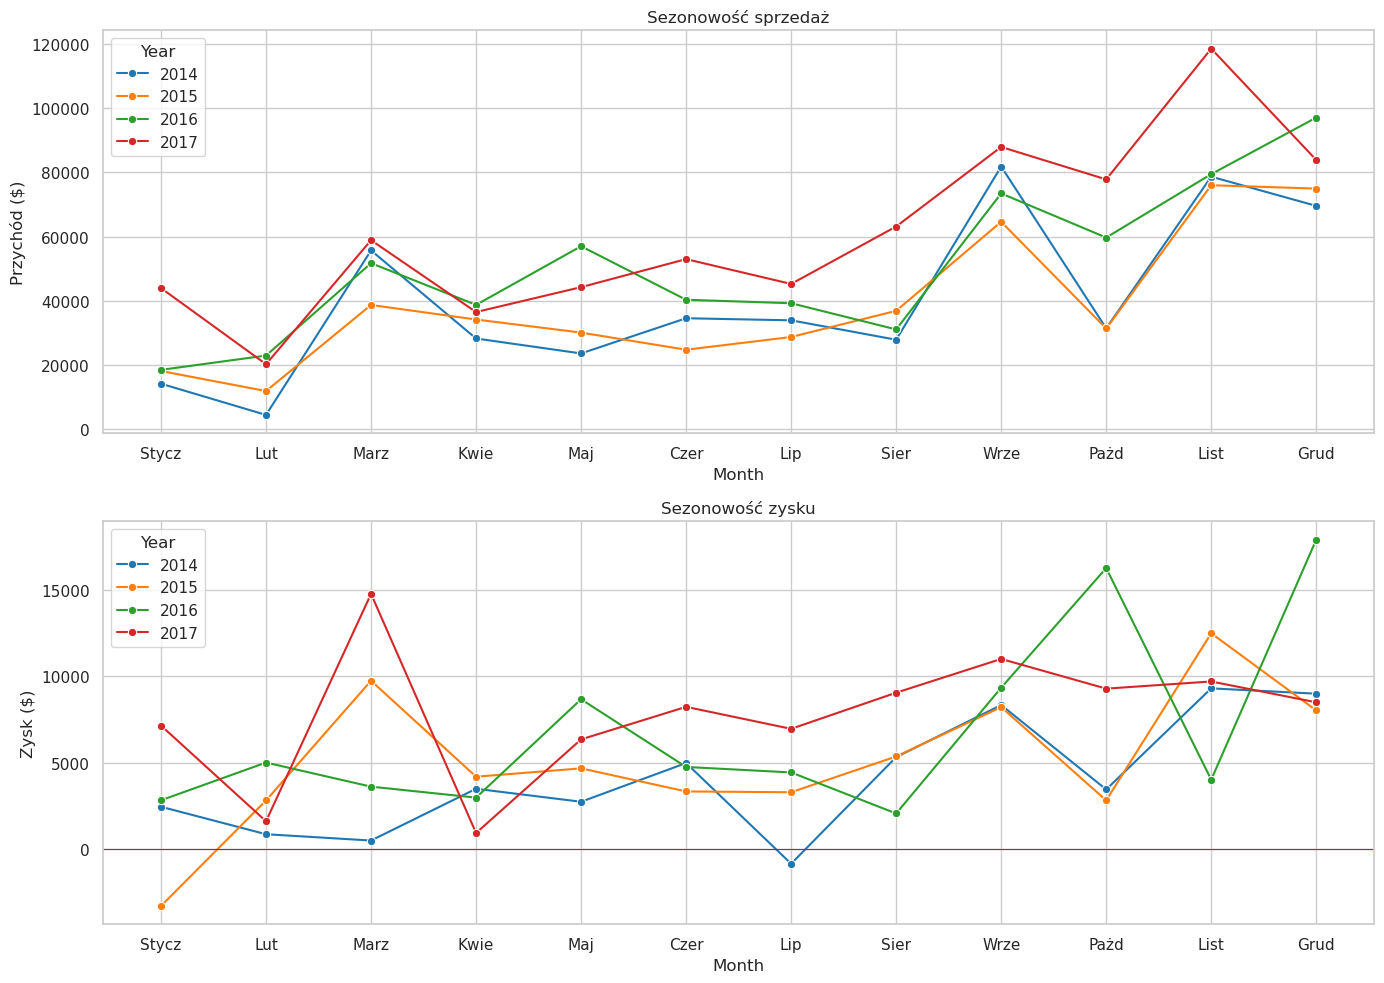

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#Sprzedaży po miesięcach
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', palette='tab10', marker='o', ax=axes[0])
axes[0].set_title('Sezonowość sprzedaż')
axes[0].set_ylabel('Przychód ($)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Stycz', 'Lut', 'Marz', 'Kwie', 'Maj', 'Czer', 'Lip', 'Sier', 'Wrze', 'Pażd', 'List', 'Grud'])

#Zysk po miesięcach
monthly_profit = df.groupby(['Year', 'Month'])['Profit'].sum().reset_index()
sns.lineplot(data=monthly_profit, x='Month', y='Profit', hue='Year', palette='tab10', marker='o', ax=axes[1])
axes[1].set_title('Sezonowość zysku')
axes[1].set_ylabel('Zysk ($)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Stycz', 'Lut', 'Marz', 'Kwie', 'Maj', 'Czer', 'Lip', 'Sier', 'Wrze', 'Pażd', 'List', 'Grud'])
axes[1].axhline(y=0, color='red', linewidth=0.8)

plt.tight_layout()
plt.show()

In [14]:
#Patrzymy co się działo w marcu 2017
march_2017 = df[(df['Year'] == 2017) & (df['Month'] == 3)]
print(march_2017.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False))

                   Sales     Profit
Sub-Category                       
Copiers       21319.8220  9185.9377
Accessories    3952.2720  1192.2330
Paper          2551.1000  1155.8497
Chairs         5524.9140  1021.4723
Phones         7413.8220   594.6338
Binders        2785.4880   577.7151
Storage        3815.4520   488.8290
Appliances     2473.6140   308.3739
Envelopes       517.0160   238.0695
Furnishings     963.2340   140.6693
Art             442.0840   115.4175
Labels          224.1000   103.2819
Machines        742.7060    62.2714
Bookcases      1928.1928     6.3412
Fasteners        24.6800     4.2346
Tables         2477.1040  -167.6296
Supplies       1716.7520  -275.8088


In [15]:
march_copiers = df[(df['Year'] == 2017) & (df['Month'] == 3) & (df['Sub-Category'] == 'Copiers')]
print(f"Liczba zamówień: {len(march_copiers)}")
print(march_copiers[['Customer Name', 'Sales', 'Profit', 'Discount']].sort_values('Sales', ascending=False))

Liczba zamówień: 6
               Customer Name      Sales     Profit  Discount
8153            Raymond Buch  13999.960  6719.9808       0.0
5562                 Jim Epp   2999.950  1439.9760       0.0
7173        Heather Kirkland   2399.960   569.9905       0.2
5568      Stephanie Ulpright    959.984   335.9944       0.2
2386  Christina VanderZanden    479.984    59.9980       0.2
8539              Karl Braun    479.984    59.9980       0.2


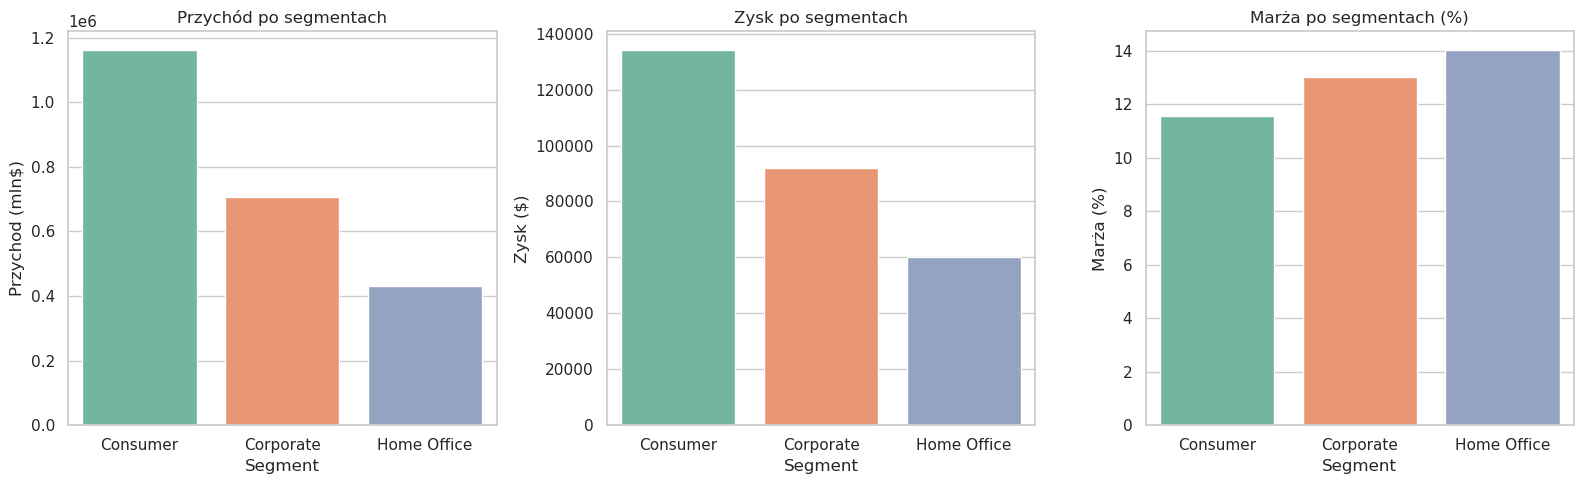

       Segment         Sales       Profit  Orders  Margin
0     Consumer  1.161401e+06  134119.2092    2586   11.55
1    Corporate  7.061464e+05   91979.1340    1514   13.03
2  Home Office  4.296531e+05   60298.6785     909   14.03


In [16]:
#Analiza segmentacji klientów
segment_data = df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()
segment_orders = df.groupby('Segment')['Order ID'].nunique().reset_index()
segment_orders.columns = ['Segment', 'Orders']
segment_data = segment_data.merge(segment_orders, on='Segment')
segment_data['Margin'] = (segment_data['Profit'] / segment_data['Sales'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=segment_data, x='Segment', y='Sales', hue='Segment', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Przychód po segmentach')
axes[0].set_ylabel('Przychod (mln$)')

sns.barplot(data=segment_data, x='Segment', y='Profit', hue='Segment', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('Zysk po segmentach')
axes[1].set_ylabel('Zysk ($)')

sns.barplot(data=segment_data, x='Segment', y='Margin', hue='Segment', legend=False, palette='Set2', ax=axes[2])
axes[2].set_title('Marża po segmentach (%)')
axes[2].set_ylabel('Marża (%)')

plt.tight_layout()
plt.show()

print(segment_data)

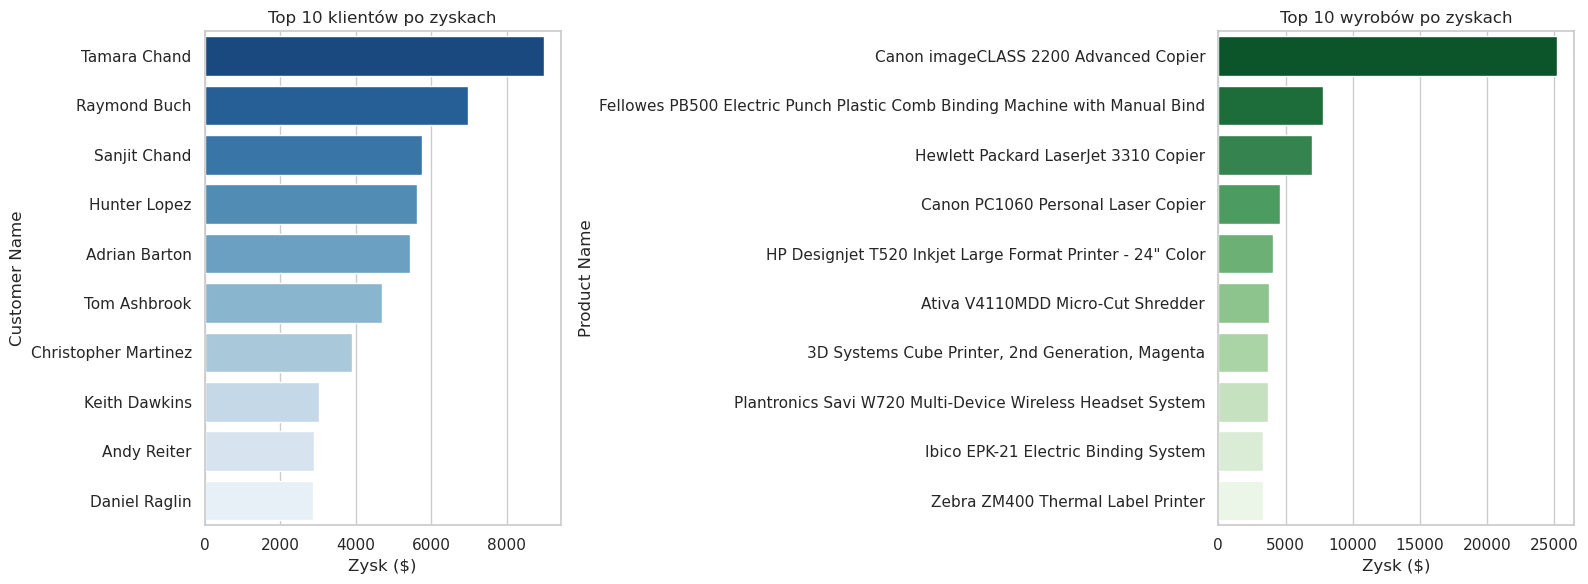

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Top 10 klientów po zyskach
top_customers = df.groupby('Customer Name')['Profit'].sum().reset_index()
top_customers = top_customers.sort_values('Profit', ascending=False).head(10)

sns.barplot(data=top_customers, x='Profit', y='Customer Name', hue='Customer Name', legend=False, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 klientów po zyskach')
axes[0].set_xlabel('Zysk ($)')

#Top 10 wyrobów po zyskach
top_products = df.groupby('Product Name')['Profit'].sum().reset_index()
top_products = top_products.sort_values('Profit', ascending=False).head(10)

sns.barplot(data=top_products, x='Profit', y='Product Name', hue='Product Name', legend=False, palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 wyrobów po zyskach')
axes[1].set_xlabel('Zysk ($)')

plt.tight_layout()
plt.show()

In [18]:
#Sprawdzenie co kupował klient top1
tamara = df[df['Customer Name'] == 'Tamara Chand']
print(tamara[['Product Name', 'Sales', 'Profit']].sort_values('Profit', ascending=False).head(5))

                                   Product Name      Sales     Profit
6826      Canon imageCLASS 2200 Advanced Copier  17499.950  8399.9760
6827  Ibico Ibimaster 300 Manual Binding System    735.980   331.1910
8338          Enermax Acrylux Wireless Keyboard    498.000   184.2600
8060                                 Xerox 1881     61.400    28.8580
3186                            Staple envelope     74.352    26.9526


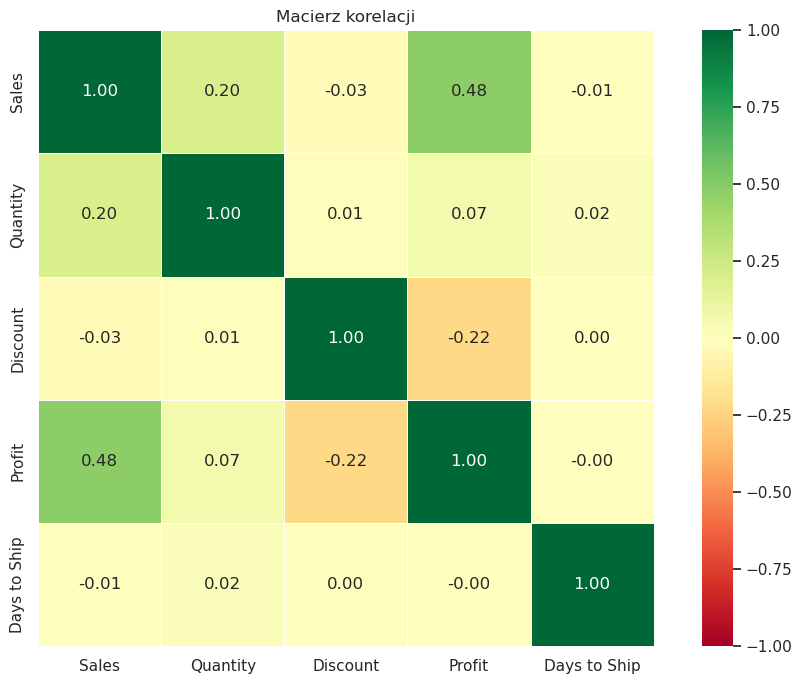

In [19]:
#Macierz korelacji
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Days to Ship']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

#Wybieramy znaki
features = ['Sales', 'Quantity', 'Discount', 'Category', 'Region', 'Segment', 'Ship Mode']
target = 'Profit'

ml_df = df[features + [target]].copy()

le = LabelEncoder()
for col in ['Category', 'Region', 'Segment', 'Ship Mode']:
    ml_df[col] = le.fit_transform(ml_df[col])

X = ml_df[features]
y = ml_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Próbka szkoleniowa: {X_train.shape}")
print(f"Próbka testowa: {X_test.shape}")

Próbka szkoleniowa: (7995, 7)
Próbka testowa: (1999, 7)


In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = ['Sales', 'Quantity', 'Discount']
categorical_features = ['Category', 'Region', 'Segment', 'Ship Mode']

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:.2f}")
print(f"R²: {r2:.3f}")

MAE: $32.56
R²: -0.155
